#California Housing Prices Project

Dataset from Kaggle

In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
!pip install xgboost
from xgboost import XGBRegressor

#Data Cleaning and Pre-processing

In [5]:
#load dataset
#when uploading to colab
df = pd.read_csv('housing.csv')
display(df.head())

#else if mounting google drive
#from google.colab import drive
#drive.mount('/content/drive') UPDATE PATH

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
df.shape

(20640, 10)

The dataframe contains 9 features to predict 1 target variable and 20640 observations.

In [7]:
df.isna().sum() #check missing values

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


The 207 rows with missing values for total_bedrooms represents roughly 1% of total data points. We will drop these rows from the data frame.

In [8]:
df = df.dropna()
df.shape

(20433, 10)

In [9]:
display(df.describe())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


median_income is measured in tens of thousands of USD and median_house_value is measured in USD. To make these numerical values consistent, median income is multiplied by 10,000 to ensure it is in USD.

In [10]:
df["median_income"] = df["median_income"]*10000

Total rooms and total bedrooms columns are dependant on the number of households in each block. By replacing these two columns with the average number of rooms and average number of bedrooms per household, we make this value comparable to other observations.

In [11]:
df["avg_bedrooms_per_household"] = df["total_bedrooms"] / df["households"]
df["avg_rooms_per_household"] = df["total_rooms"] / df["households"]
print("avg_bedrooms_per_household")
display(df["avg_bedrooms_per_household"].describe())
print("avg_rooms_per_household")
display(df["avg_rooms_per_household"].describe())

avg_bedrooms_per_household


,avg_bedrooms_per_household
count,20433.000000
mean,1.097062
std,0.476104
min,0.333333
25%,1.006029
50%,1.048889
75%,1.099631
max,34.066667


avg_rooms_per_household


,avg_rooms_per_household
count,20433.000000
mean,5.431344
std,2.482946
min,0.846154
25%,4.441441
50%,5.230769
75%,6.052381
max,141.909091


Mean of average number of bedrooms per household is 1.1 and mean of average number of rooms per household is 5.4. Minimum average numbers are 0.33 bedrooms per household and 0.85 total rooms per household. This suggests there are blocks where there are more households than bedrooms and rooms.

This could be a classification technicality, where spaces in a building are not classified as "bedrooms" or "rooms" resulting in instances where there are more households in a block than there are total rooms or bedrooms.

In [12]:
a = df['households']>df['total_rooms']
display(a.describe())

,0
count,20433
unique,2
top,False
freq,20431


20433 -20431 = 2 instances where households > total_rooms

In [13]:
b = df['households']>df['total_bedrooms']
display(b.describe())

,0
count,20433
unique,2
top,False
freq,16081


20433 - 16081 = 4352 instances where households > total_bedrooms

Dividing the population by households shows the average household size. Like with average rooms there is a massive spread of household populations with averages ranging from 0.69 to 1243.33

In [14]:
#create avg_house_pop = population / households
df["avg_house_population"] = df["population"] / df["households"]
print("avg_house_population")
display(df["avg_house_population"].describe())

avg_house_population


,avg_house_population
count,20433.000000
mean,3.071533
std,10.438269
min,0.692308
25%,2.429032
50%,2.817582
75%,3.281513
max,1243.333333


avg_house_population < 1 if population < households. This implies the existance of empty rooms or buildings.

Representing categorical values with numerical dummy values. They cannot be manually assigned numbers as we cannot establish a linear relationship between increasing value of a numerical variable and the difference between the present categories.

In [15]:
display(df["ocean_proximity"].unique())

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [16]:
df = pd.get_dummies(df)

In [17]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,avg_bedrooms_per_household,avg_rooms_per_household,avg_house_population,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,83252.0,452600.0,1.023810,6.984127,2.555556,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,83014.0,358500.0,0.971880,6.238137,2.109842,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,72574.0,352100.0,1.073446,8.288136,2.802260,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,56431.0,341300.0,1.073059,5.817352,2.547945,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,38462.0,342200.0,1.081081,6.281853,2.181467,False,False,False,True,False


From above descriptive statistics, we know that there some outliers in certain features. We will leave these outliers in for now and remove them from a duplicated dataframe later and see how these two different dataframes perform in the same models to see the impact of outliers on model performance.

#Data Visualisation

Text(0.5, 1.0, 'Correlation Matrix of Features')

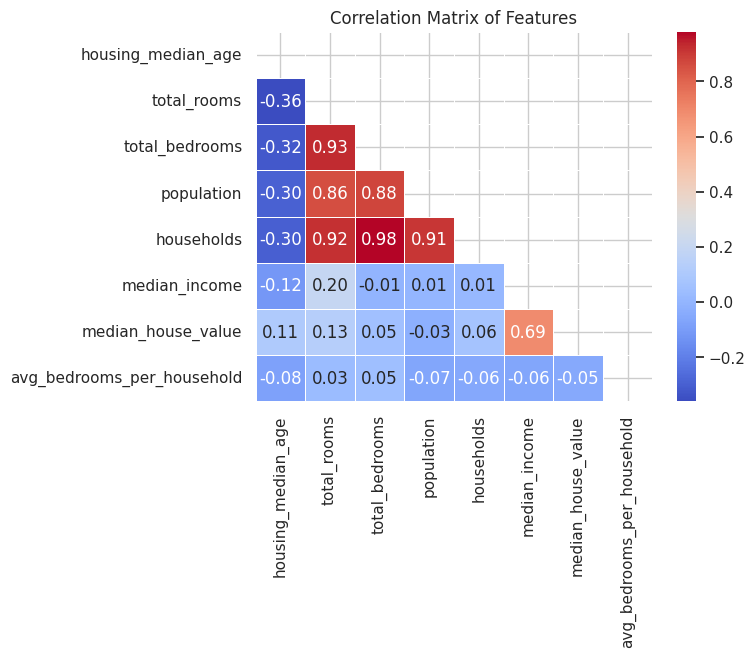

In [18]:
df2 = df.iloc[:,2:10]
# Set plot style
sns.set_theme(style="whitegrid")

# Correlation Matrix Heatmap
#plt.figure(figsize=(10, 8))
corr_matrix = df2.corr()

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, mask=mask)
plt.title("Correlation Matrix of Features")

Median income seems to be most correlated with median house value.

Text(0, 0.5, 'Frequency')

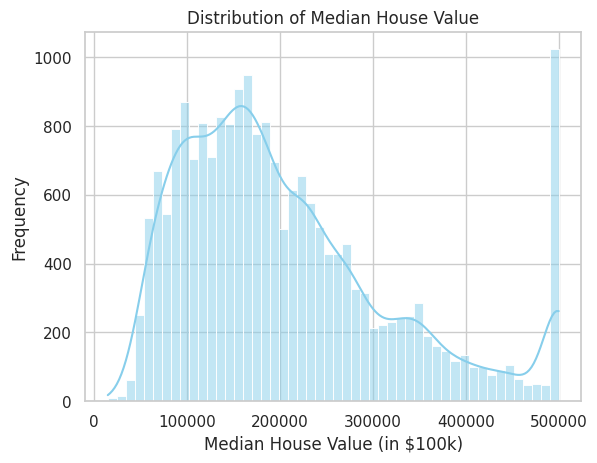

In [19]:
#Histogram of Target Variable (MedHouseVal)
#plt.figure(figsize=(8, 6))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value (in $100k)")
plt.ylabel("Frequency")

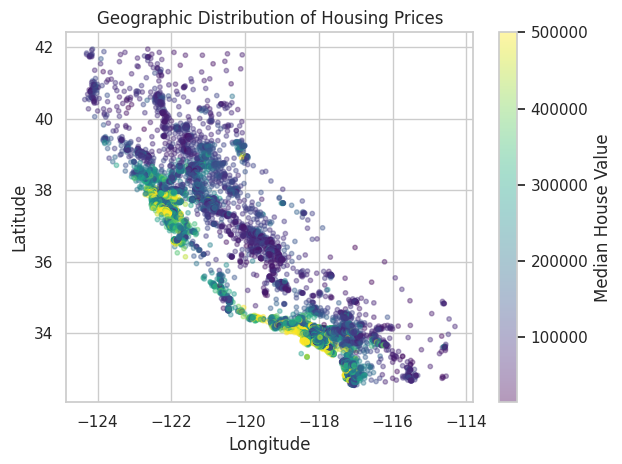

In [20]:
#Geographic Scatter Plot (Latitude vs Longitude)
#plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'], cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Median House Value')
plt.title("Geographic Distribution of Housing Prices")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

Coastal properties generally have larger median house value compared to inland properties. Density does not seem to have a distinct impact on house value.

#Data Modelling

First, we will explore Linear Regression.
Linear Regression models the target variable using all features provided using a formula of the form Target = a1 * f1 + a2 * f2 + ... + an * fn ,
where (f1, f2, ..., fn) are the features in the model, n is the total number of features and (a1, a2, ..., an) are the coefficients assigned by the model.

Performace of a regular Linear Regression model depends largely on the features used. So we are able to drop some features or construct other using given data to represent some pattern in the data.

Ridge Regression and Lasso Regression are model that apply ridge and lasso regularisation respectively to Linear Regression models.

Regularisation is a technique that adds a penalty term to the loss function in order to penalise the model when predictions made are different to true labels.

In [40]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso

linear_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42, max_iter=5000),
    "Lasso Regression": Lasso(random_state=42, max_iter=5000)
}

Ridge adds the squared magnitude of the coefficients to the loss function and shrinks coefficients to zero. This reduces the effect of certain features on the target variable but never eliminates it entirely. This is primarily helpful for highly correlated features.

On the other hand, Lasso adds the absolute value of the coefficients to the loss function and can force less important features to zero. This doubles as a feature selection tool.

In [32]:
#define a function to simplify fitting and training in the future
def fit_train(X, y, models):
  # 80% data for training and 20% for testing
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # Scale features
  scaler = StandardScaler()
  X_train_scaled = scaler.fit_transform(X_train)
  X_test_scaled = scaler.transform(X_test)
  # Evaluate Models
  print(f"{'Model':<20} | {'RMSE':<10} | {'R² Score':<10}")
  print("-" * 45)

  for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"{name:<20} | {rmse:.4f}     | {r2:.6f}")

In [33]:
#Prepare data
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

fit_train(X,y, linear_models)

Model                | RMSE       | R² Score  
---------------------------------------------
Linear Regression    | 69874.4040     | 0.642971
Ridge Regression     | 69872.6554     | 0.642989
Lasso Regression     | 69873.8726     | 0.642977


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.441e+12, tolerance: 2.164e+10
  model = cd_fast.enet_coordinate_descent(


We want to drop highly correlated features to see the impact on model performance.

In [34]:
X_c = df.drop(['total_rooms', 'avg_bedrooms_per_household', 'population', 'median_house_value'], axis=1)
fit_train(X_c,y,linear_models)

Model                | RMSE       | R² Score  
---------------------------------------------
Linear Regression    | 72229.2764     | 0.618501
Ridge Regression     | 72229.5101     | 0.618498
Lasso Regression     | 72229.3539     | 0.618500


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.641e+12, tolerance: 2.164e+10
  model = cd_fast.enet_coordinate_descent(


Visualizing outliers in numerical features of X:


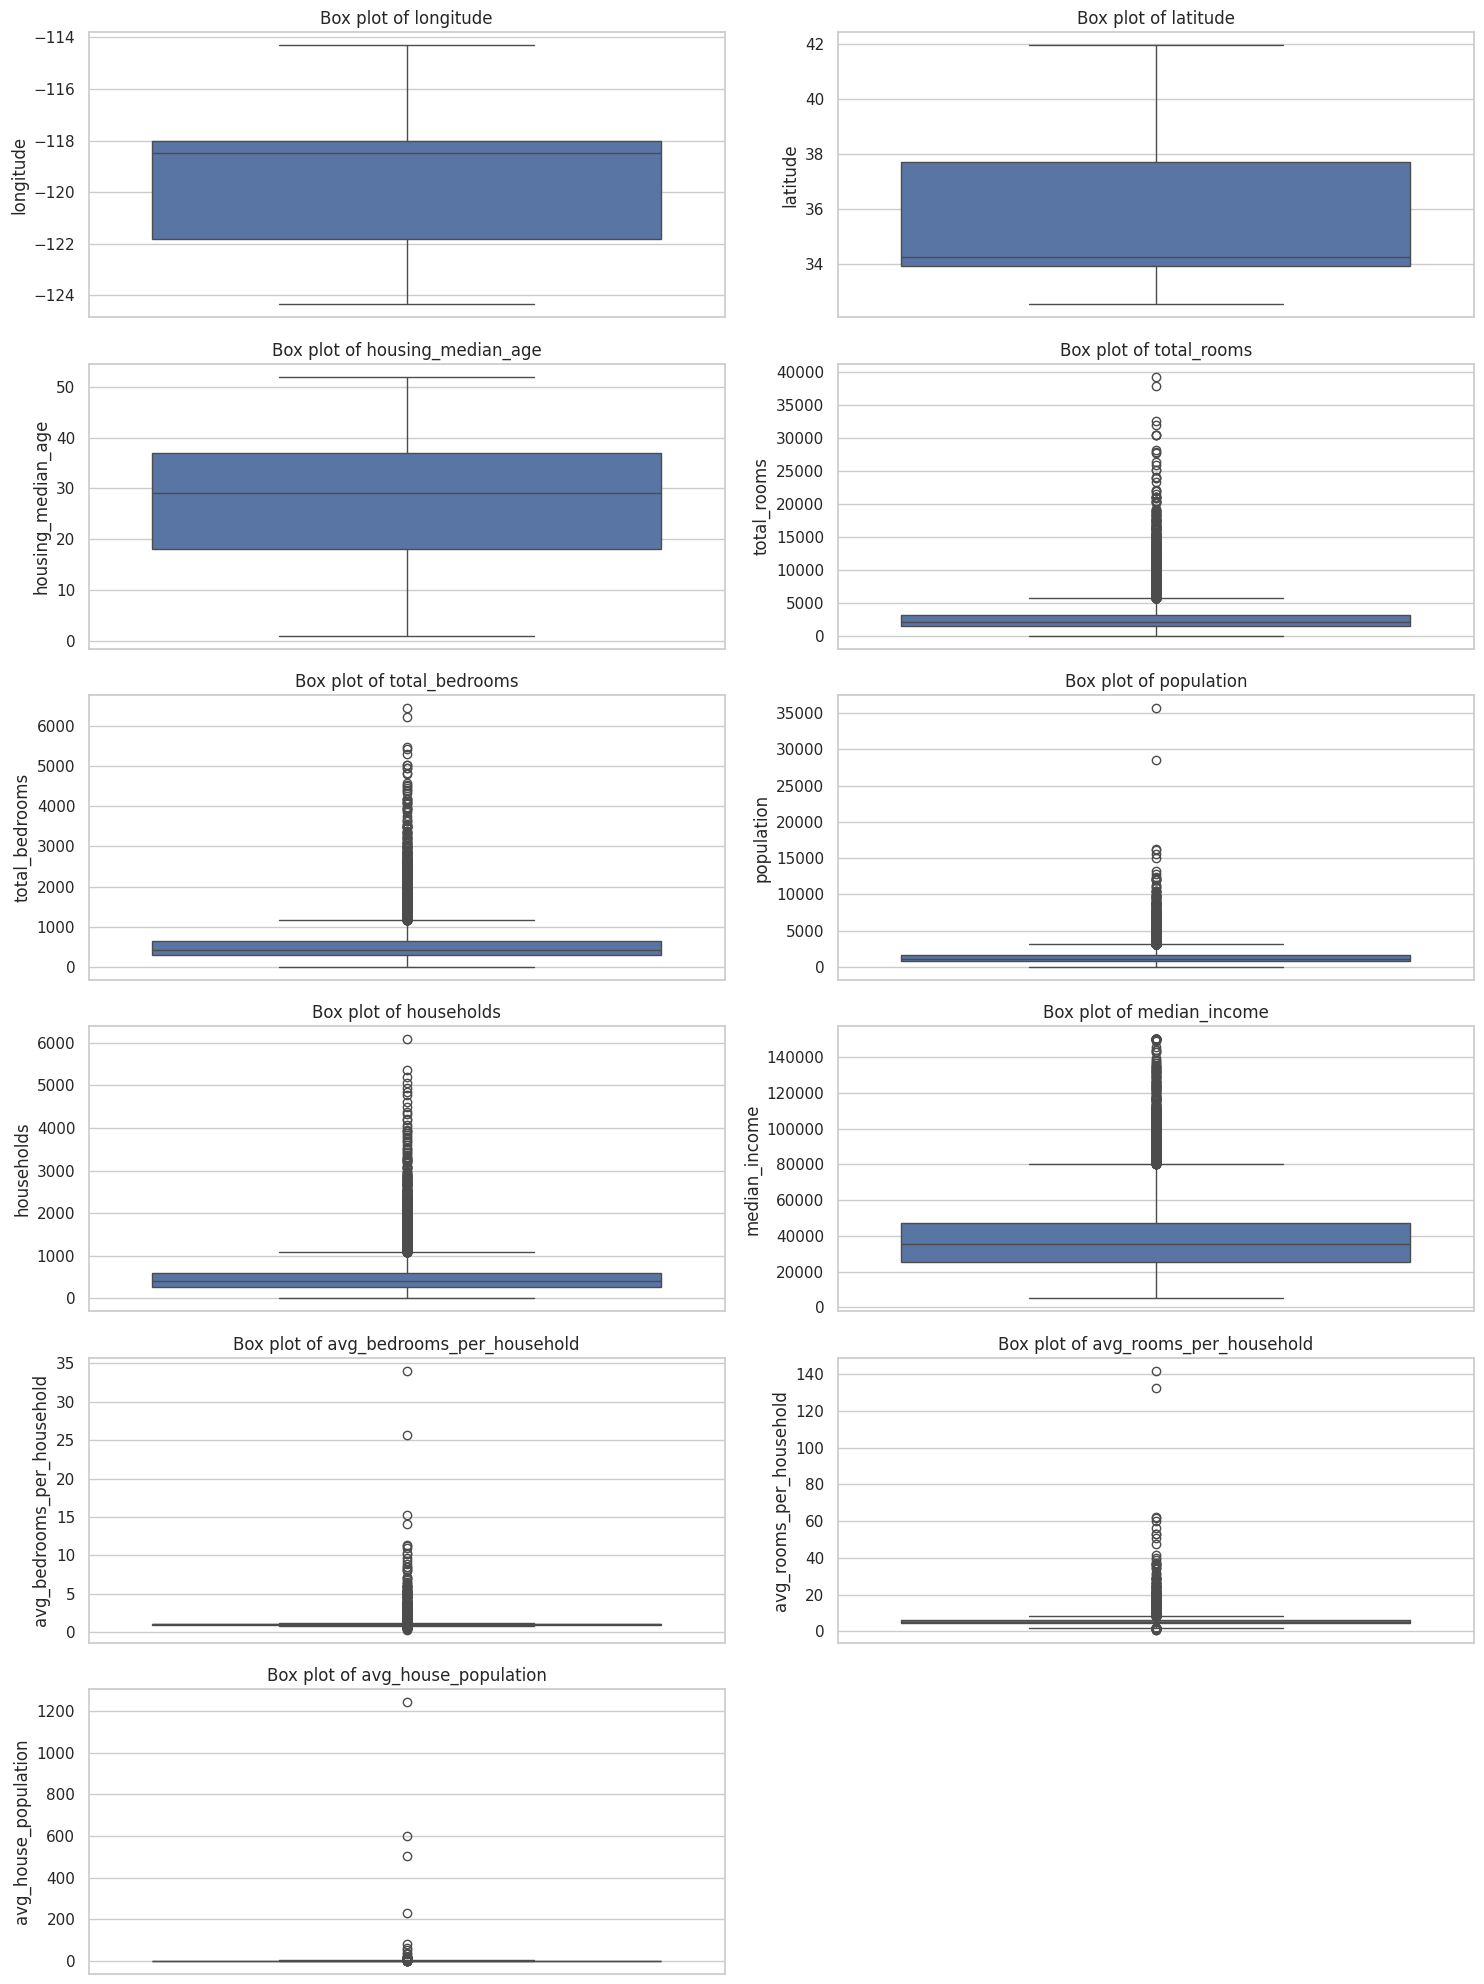

Number of rows before outlier removal: 20433
Number of outlier rows identified across all specified columns: 4289
Number of rows after outlier removal: 16144

Shape of X before outlier removal: (20433, 16)
Shape of X after outlier removal: (16144, 16)

Shape of y before outlier removal: (20433,)
Shape of y after outlier removal: (16144,)


In [35]:
# Identify numerical columns in X for outlier visualization and removal
numerical_cols = [
    'longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms',
    'population', 'households', 'median_income', 'avg_bedrooms_per_household',
    'avg_rooms_per_household', 'avg_house_population'
]

print("Visualizing outliers in numerical features of X:")
plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_cols):
    plt.subplot(6, 2, i + 1) # Arrange plots in a grid
    sns.boxplot(y=df[col]) # Using df[col] to access the original data for plotting
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

# Function to remove outliers using the IQR method
def remove_outliers_iqr(df_input, columns):
    df_out = df_input.copy()
    outlier_indices = np.array([])
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Identify indices of outliers for the current column
        outliers = df_out[(df_out[col] < lower_bound) | (df_out[col] > upper_bound)].index
        outlier_indices = np.concatenate((outlier_indices, outliers))

    # Get unique outlier indices to avoid dropping rows multiple times
    outlier_indices = np.unique(outlier_indices).astype(int)

    print(f"Number of rows before outlier removal: {len(df_out)}")
    print(f"Number of outlier rows identified across all specified columns: {len(outlier_indices)}")
    df_out = df_out.drop(outlier_indices)
    print(f"Number of rows after outlier removal: {len(df_out)}")
    return df_out

# Create a new DataFrame without outliers based on the numerical features of X
df_no_outliers = remove_outliers_iqr(df, numerical_cols)

# Prepare X and y from the new DataFrame without outliers
X_no_outliers = df_no_outliers.drop('median_house_value', axis=1)
y_no_outliers = df_no_outliers['median_house_value']

print("\nShape of X before outlier removal:", X.shape)
print("Shape of X after outlier removal:", X_no_outliers.shape)
print("\nShape of y before outlier removal:", y.shape)
print("Shape of y after outlier removal:", y_no_outliers.shape)


In [36]:
fit_train(X_no_outliers,y_no_outliers, linear_models)

Model                | RMSE       | R² Score  
---------------------------------------------
Linear Regression    | 62547.6600     | 0.653311
Ridge Regression     | 62547.3061     | 0.653315
Lasso Regression     | 62547.2682     | 0.653315


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.753e+12, tolerance: 1.466e+10
  model = cd_fast.enet_coordinate_descent(


In [37]:
Xc_no_outliers = df_no_outliers.drop(['total_rooms', 'avg_bedrooms_per_household', 'population', 'median_house_value'], axis=1)
yc_no_outliers = df_no_outliers['median_house_value']
fit_train(Xc_no_outliers ,yc_no_outliers,linear_models)

Model                | RMSE       | R² Score  
---------------------------------------------
Linear Regression    | 62751.7094     | 0.651045
Ridge Regression     | 62753.2613     | 0.651028
Lasso Regression     | 62751.9625     | 0.651042


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.704e+12, tolerance: 1.466e+10
  model = cd_fast.enet_coordinate_descent(


In [ ]:
#visualisation of best models and their formulas

We can see that feature selection and shrinkage can affect performance of a linear regression model. However, for this large dataset, a linear regression model is not complex enough to represent patterns present within multiple variables.

##Trees

In [43]:
tree_models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42), # Added random_state for consistency
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42)
}

In [44]:
print("\n--- Performance with all features (X) using tree models ---")
fit_train(X, y, tree_models)

print("\n--- Performance with dropped features (X_c) using tree models ---")
fit_train(X_c, y, tree_models)

print("\n--- Performance with no outliers (X_no_outliers) using tree models ---")
fit_train(X_no_outliers, y_no_outliers, tree_models)



--- Performance with all features (X) using tree models ---
Model                | RMSE       | R² Score  
---------------------------------------------
Decision Tree        | 70048.6394     | 0.641189
Random Forest        | 51269.0804     | 0.807789
XGBoost Regressor    | 47167.6703     | 0.837312

--- Performance with dropped features (X_c) using tree models ---
Model                | RMSE       | R² Score  
---------------------------------------------
Decision Tree        | 70580.3631     | 0.635721
Random Forest        | 50919.8076     | 0.810399
XGBoost Regressor    | 46677.1316     | 0.840678

--- Performance with no outliers (X_no_outliers) using tree models ---
Model                | RMSE       | R² Score  
---------------------------------------------
Decision Tree        | 68315.6328     | 0.586421
Random Forest        | 48217.7114     | 0.793970
XGBoost Regressor    | 44865.2666     | 0.821623
